# Neural Network Based Speech Recognition Using MFCC Features
### Based on: *Barua et al., ICIEV 2014*
### Dataset: Google Speech Commands v0.02

---

##  Project Overview

This notebook implements a **two-stage, speaker-gated speech recognition system** based on the architecture described in Barua et al. (ICIEV 2014). The system is trained on the **Google Speech Commands v0.02** dataset and uses **Mel-Frequency Cepstral Coefficients (MFCCs)** as the core feature representation for all audio.

- **Stage 1 — Speaker Recognition (Network 1):** A binary MLP classifier that acts as a security gatekeeper. Given an audio sample, it decides whether the speaker is the pre-registered *authorized* user or an *unauthorized* speaker.

- **Stage 2 — Command Recognition (Network 2):** A 7-class MLP classifier that identifies which of 6 core commands was spoken (`on`, `off`, `stop`, `go`, `up`, `down`), or rejects the audio as `unknown` if it does not match any of the target commands.

### Full Pipeline
```
Audio Files → MFCC Extraction → Data Preparation → Train Network 1 (Speaker Gate) → Train Network 2 (Command Classifier) → Inference → Results
```

### Member Responsibilities
| Member | Role |
|--------|------|
| Member 1 | Data Filtering — dataset audit, speaker selection, label creation, data assembly |
| Member 2 | MFCC Extraction — feature extraction function, extraction loop, visualization |
| Member 3 | Dataset Builder — feature aggregation, train/test split |
| Member 4 | Network 1 — speaker model training, evaluation, loss curves, confusion matrix |
| Member 5 | Network 2 — command model training, evaluation, loss curves, confusion matrix |
| Member 6 | Integration — `recognize()` pipeline, end-to-end test, final summary |


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
import random
from collections import defaultdict, Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm

In [12]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("yashdogra/speech-commands")

print("Dataset path:", path)


Using Colab cache for faster access to the 'speech-commands' dataset.
Dataset path: /kaggle/input/speech-commands


In [ ]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)  # also seed numpy for full reproducibility

## Member 1 — Data Filtering

This section handles all data preparation before any model is trained. The steps are:

1. **Dataset Audit:** Count audio files per command class to check for imbalance or corrupted folders.
2. **Command Filtering:** Select 6 phonetically distinct, naturally balanced command words.
3. **Speaker Selection:** Identify and isolate a single authorized speaker from the dataset; undersample unauthorized speakers to achieve a 1-to-1 balance for Network 1.
4. **Unknown Class Construction:** Sample a set of audio files from non-command folders to serve as a "catch-all" rejection class for Network 2.
5. **Label Encoding:** Map string labels to integer indices required by the neural network.
6. **Data Assembly:** Build the final file path lists and integer label arrays for both networks, plus a deduplicated union for MFCC extraction.


In [14]:
# 1. Initial Data Exploration (Dataset Audit)
# Problem: Real-world datasets often suffer from severe class imbalance, or contain corrupted folders (like _background_noise_).
# Why: We must count the audio files per command to audit the dataset's health.
# If a class has significantly fewer files, the neural network will be biased against it.

In [15]:
commands = {d.name: len(list(d.glob('*.wav'))) for d in Path(path).iterdir() if d.is_dir() and d.name != "_background_noise_"}

print(f"Total Commands: {len(commands)}\n\n{'Command Name':<20} | File Count\n" + "-" * 40)
for cmd, count in sorted(commands.items()):
    print(f"{cmd:<20} | {count}")

Total Commands: 35

Command Name         | File Count
----------------------------------------
backward             | 1664
bed                  | 2014
bird                 | 2064
cat                  | 2031
dog                  | 2128
down                 | 3917
eight                | 3787
five                 | 4052
follow               | 1579
forward              | 1557
four                 | 3728
go                   | 3880
happy                | 2054
house                | 2113
learn                | 1575
left                 | 3801
marvin               | 2100
nine                 | 3934
no                   | 3941
off                  | 3745
on                   | 3845
one                  | 3890
right                | 3778
seven                | 3998
sheila               | 2022
six                  | 3860
stop                 | 3872
three                | 3727
tree                 | 1759
two                  | 3880
up                   | 3723
visual               | 1592
wow      

In [16]:
# 2. Filter Target Commands
# Problem: Training a model on 30+ overlapping words causes high confusion and drops accuracy.
# Decision: We strictly isolate 6 core basic_controls ('on', 'off', 'stop', 'go', 'up', 'down').
# Why these 6?: First.. they are "Binary Acoustic Pairs" with maximum phonetic contrast...
# Second.. they all naturally have almost the exact same number of files (~3800).. which perfectly balances the dataset without us needing to fake or duplicate any data...

In [17]:
# Setup: Setting the random seed for reproducibility
random.seed(42)

basic_controls = ['on', 'off', 'stop', 'go', 'up', 'down']
selected = {k: v for k, v in commands.items() if k in basic_controls}
for cmd, count in selected.items():
    print(f"{cmd:<10} | {count} files")

N_per_cmd = 600  # balanced samples per class — used for commands AND unknown


off        | 3745 files
go         | 3880 files
on         | 3845 files
down       | 3917 files
stop       | 3872 files
up         | 3723 files


In [18]:
# 3. Speaker Selection & Data Balancing
# Problem: Stage 1 is a Speaker Recognition Gatekeeper. If we train it on 1 person (~80 files) vs everyone else (~20,000 files),..
# the model will suffer from extreme false-negative bias (it will simply learn to always say "Unauthorized" to get 99% accuracy).

In [19]:
# Step A: Isolating the Core Identity (Authorized Speaker)...
# Problem: A speaker with missing words creates blind spots.. while a speaker with too few files makes the Gatekeeper weak...
# Decision: We strictly filter for users who successfully recorded all 6 commands first.. THEN we isolate the single target user with the absolute highest file count...
spk_files = defaultdict(list)
for cmd in basic_controls:
    for f in Path(path).joinpath(cmd).glob('*.wav'):
        spk_files[f.name.split('_')[0]].append(f)

balanced = {s: fs for s, fs in spk_files.items() if len({f.parent.name for f in fs}) == len(basic_controls)}
auth_speaker, auth_files = max(balanced.items(), key=lambda x: len(x[1]))

# Step B: Strict 1-to-1 Undersampling...
# Decision: We pull a random sample of unauthorized files to exactly mirror our Core Identity's file count...
unauth_files = random.sample([f for s, fs in spk_files.items() if s != auth_speaker for f in fs], len(auth_files))

print(f"Authorized Speaker ID: {auth_speaker} ({len(auth_files)} files)")

Authorized Speaker ID: 893705bb (78 files)


### Reserving Integration Test Files & Mounting Google Drive

Before any data is assembled for training, a small set of audio files is **permanently reserved** for the final end-to-end system test. These files will:
- **Never appear** in `X_spk`, `X_cmd`, or any training/validation split.
- Be copied to **Google Drive** under `MyDrive/speech_test_files/` for safe, persistent storage.
- Be loaded back from Drive at the end of the notebook to test the fully trained pipeline on truly unseen audio.

Three groups of files are reserved:
- `authorized/` — files from the registered authorized speaker.
- `unauthorized/` — files from unauthorized speakers.
- `unknown/` — files from non-command audio folders (reserved after `all_other_files` is assembled in the next cell).

This separation is done here, **immediately after** `auth_files` and `unauth_files` are defined, so there is zero chance of these files leaking into the training pipeline.


In [96]:
from google.colab import drive
from collections import defaultdict
from pathlib import Path
import shutil, json

# ── Mount Drive ──────────────────────────────────────────────────────────────
drive.mount('/content/drive')

DRIVE_TEST_DIR = Path('/content/drive/MyDrive/speech_test_files')
MANIFEST_FILE  = DRIVE_TEST_DIR / 'manifest.json'
DRIVE_TEST_DIR.mkdir(parents=True, exist_ok=True)

# ── Load manifest if it exists ────────────────────────────────────────────────
# The manifest stores each reserved file as a relative path (e.g. "on/abc_nohash_0.wav").
# Relative paths are portable: if the Kaggle cache root (`path`) changes between
# sessions we just rejoin with the new root — no stale absolute paths.
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE) as fh:
        manifest = json.load(fh)
    print('Manifest found — reusing existing test split (no random sampling will occur).')
else:
    manifest = {}
    print('No manifest found — creating fresh test split.')


def _abs_paths(key):
    """Reconstruct absolute paths from manifest relative paths."""
    return set(str(Path(path) / rel) for rel in manifest[key])


# ════════════════════════════════════════════════════════════════════════════
# AUTHORIZED TEST SET
# ════════════════════════════════════════════════════════════════════════════
auth_dir = DRIVE_TEST_DIR / 'authorized'

if 'authorized' in manifest:
    # Reuse: rebuild exact path set from manifest (no filename matching)
    auth_test_paths = _abs_paths('authorized')

else:
    # Fresh: group by command folder, pick 1 file per command
    auth_by_cmd = defaultdict(list)
    for f in auth_files:
        cmd = Path(str(f)).parent.name
        if cmd in basic_controls:
            auth_by_cmd[cmd].append(str(f))

    reserved = []
    for cmd in sorted(auth_by_cmd):               # sorted keys → deterministic
        candidates = sorted(auth_by_cmd[cmd])     # sorted list  → deterministic
        reserved.append(random.choice(candidates))

    auth_test_paths = set(reserved)

    auth_dir.mkdir(parents=True, exist_ok=True)

    for fp in reserved:
        fp = Path(fp)
        dest_dir = auth_dir / fp.parent.name
        dest_dir.mkdir(parents=True, exist_ok=True)

        dest = dest_dir / fp.name
        if not dest.exists():
            shutil.copy(fp, dest)

    # Store relative paths so the manifest is portable across sessions
    manifest['authorized'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]

# Exact path removal — immune to filename collisions
auth_files = [f for f in auth_files if str(f) not in auth_test_paths]
print(f'Authorized   — reserved: {len(auth_test_paths)},  training pool: {len(auth_files)}')


# ════════════════════════════════════════════════════════════════════════════
# UNAUTHORIZED TEST SET
# ════════════════════════════════════════════════════════════════════════════
unauth_dir = DRIVE_TEST_DIR / 'unauthorized'

if 'unauthorized' in manifest:
    unauth_test_paths = _abs_paths('unauthorized')

else:
    unauth_by_cmd = defaultdict(list)
    for f in unauth_files:
        cmd = Path(str(f)).parent.name
        if cmd in basic_controls:
            unauth_by_cmd[cmd].append(str(f))

    reserved = []
    for cmd in sorted(unauth_by_cmd):
        candidates = sorted(unauth_by_cmd[cmd])
        reserved.append(random.choice(candidates))

    unauth_test_paths = set(reserved)

    unauth_dir.mkdir(parents=True, exist_ok=True)
    for fp in reserved:
        dest = unauth_dir / Path(fp).name
        if not dest.exists():
            shutil.copy(fp, str(dest))

    manifest['unauthorized'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]

unauth_files = [f for f in unauth_files if str(f) not in unauth_test_paths]
print(f'Unauthorized — reserved: {len(unauth_test_paths)},  training pool: {len(unauth_files)}')

# Manifest is NOT saved yet — we wait until the unknown cell finishes
# so the file is written once with all three groups complete.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No manifest found — creating fresh test split.
Authorized   — reserved: 6,  training pool: 66
Unauthorized — reserved: 6,  training pool: 66


In [21]:
# 4. Architecting the "Noise Gate" (The Unknown Class)
# Problem: A neural network with tunnel vision (only knowing 6 words) will confidently
#          hallucinate and classify a dog's bark as "up".
# Decision: We inject a 7th 'catch-all' class to teach the model the art of rejection.
#
# FIX — Balanced unknown class:
# The original approach used 3800 unknown files (claiming it matched the command average),
# but this created a severe 37% class imbalance. We now use exactly N_per_cmd=600 files
# so all 7 classes have identical representation in training.


In [22]:
# FIX — Class Imbalance: The original code sampled 3800 unknown files,
# dwarfing the 600 per command class. This caused the model to always predict
# "unknown" (37% of data) to maximize accuracy — visible as inflated unknown
# counts in the confusion matrix.
#
# We now sample exactly N_per_cmd unknown files to perfectly balance all 7 classes.

all_other_files = [f for f in Path(path).glob('*/*.wav')
                   if f.parent.name not in basic_controls
                   and f.name.split('_')[0] != auth_speaker]

# Sample exactly N_per_cmd (600) unknown files — matches all other classes
# RENAMED from 'unknown_files' → 'unknown_noise_sample'
# Reason: 'unknown_files' gets redefined later (in Data Assembly) as the 3800-file training set.
# This small 600-file preview is only used here to demonstrate the pool size — it is NOT used in training.
unknown_noise_sample = random.sample(all_other_files, N_per_cmd)
print(f"Unknown pool size: {len(all_other_files)} files available")
print(f"Preview sample (not used in training): {len(unknown_noise_sample)} files")


Unknown pool size: 82668 files available
Preview sample (not used in training): 600 files


In [97]:
N_INTEGRATION_TEST = 6
unknown_dir = DRIVE_TEST_DIR / 'unknown'

if 'unknown' in manifest:
    unknown_test_paths = _abs_paths('unknown')

else:
    # Group by non-command folder, pick 1 file per folder for diversity
    unknown_by_folder = defaultdict(list)
    for f in all_other_files:
        folder = Path(str(f)).parent.name
        unknown_by_folder[folder].append(str(f))

    # sorted() on keys → same folder set chosen for the same seed
    sample_folders = random.sample(
        sorted(unknown_by_folder.keys()),
        min(N_INTEGRATION_TEST, len(unknown_by_folder))
    )

    reserved = [
        random.choice(sorted(unknown_by_folder[folder]))  # sorted → deterministic
        for folder in sample_folders
    ]

    unknown_test_paths = set(reserved)

    unknown_dir.mkdir(parents=True, exist_ok=True)
    for fp in reserved:
        dest = unknown_dir / Path(fp).name
        if not dest.exists():
            shutil.copy(fp, str(dest))

    manifest['unknown'] = [
        str(Path(fp).relative_to(path)) for fp in reserved
    ]

# Exact path removal
all_other_files = [f for f in all_other_files if str(f) not in unknown_test_paths]
print(f'Unknown      — reserved: {len(unknown_test_paths)},  training pool: {len(all_other_files)}')

# ── Save manifest (single atomic write after all three groups are finalised) ──
# On a clean first run this writes all three groups at once.
# On a rerun where all three keys already existed, nothing changes — same data.
# On a partial-failure rerun (Cell 1 ran, Cell 2 crashed before this line),
# the manifest file still doesn't exist, so the next full run recreates
# everything from scratch with the same seed → same files.
with open(MANIFEST_FILE, 'w') as fh:
    json.dump(manifest, fh, indent=2)
print(f'\nManifest saved  →  {MANIFEST_FILE}')

# ── Final summary ─────────────────────────────────────────────────────────────
print(f'\nDrive test directory         : {DRIVE_TEST_DIR}')
print(f'Authorized training pool     : {len(auth_files)}')
print(f'Unauthorized training pool   : {len(unauth_files)}')
print(f'Unknown training pool        : {len(all_other_files)}')
print('\nAll integration test files safely reserved and excluded from training.')


Unknown      — reserved: 6,  training pool: 82656

Manifest saved  →  /content/drive/MyDrive/speech_test_files/manifest.json

Drive test directory         : /content/drive/MyDrive/speech_test_files
Authorized training pool     : 66
Unauthorized training pool   : 66
Unknown training pool        : 82656

All integration test files safely reserved and excluded from training.


In [24]:
# 5. Create Digital Labels
# Problem: Neural Networks cannot calculate Loss using string text like "on" or "authorized".
# Decision: Map human-readable text into clean integers.
# Why: Network 1 needs binary targets (1=Auth, 0=Unauth), and Network 2 needs categorical integers (0 to 6).

In [25]:
command_labels = {cmd: idx for idx, cmd in enumerate(list(basic_controls) + ['unknown'])}
speaker_labels = {'authorized': 1, 'unauthorized': 0}

In [26]:
# Why assemble a single unified list?
# 1. Delivering 3 or 4 separate lists (auth, unauth, unknown) makes Member 2's job a nightmare.
# 2. They would have to write multiple separate loops to extract MFCC features.
# Decision: We merge everything into a standard ML pipeline (one X list, aligned with y targets).

---
### Data Assembly Design — Two Key Decisions for Network 2

**Decision 1 — Who trains Network 2:**
The original design trained Network 2 on only the authorized speaker's data (~78 files across 6 commands).
This created extreme class imbalance — `{0:18, 1:15, ..., 6:3039}` — because the authorized speaker had very few files per command. The model learned to always predict `unknown` to maximize accuracy.

**Correction:** Network 2 now trains on **all speakers'** command data (roughly ~3800 files per command class, unfiltered). Network 1 is the authorization gatekeeper — Network 2 only needs to classify what the command *is*, not who said it.

**Decision 2 — Balancing the unknown class:**
The unknown class (audio from non-command folders) is sampled to match the per-command file count (~3800), so that all 7 classes have approximately equal representation in the training data. This prevents the model from learning to over-predict `unknown` due to a class-size advantage.

> **Note:** The variable `N_per_cmd = 600` defined in the setup cell is used **only** for the initial `unknown_files` sample in the Noise Gate cell. It is overwritten in the data assembly cell below, where both command classes and the unknown class are set to ~3800 files each for Network 2. The final class distribution is approximately `{0:3800, 1:3800, 2:3800, 3:3800, 4:3800, 5:3800, 6:3800}`.


In [27]:
# ── Assemble data for Network 1 (Speaker Recognition) ──────────────────────
# Network 1 only needs: authorized vs unauthorized
# We use auth_files + unauth_files (no unknown needed — binary task)
X_spk = [str(f) for f in auth_files + unauth_files]
y_speaker = [1] * len(auth_files) + [0] * len(unauth_files)

# ── Assemble data for Network 2 (Command Recognition) ───────────────────────
# FIX: Network 2 should train on ALL speakers' command data so each class
# has enough samples. Network 1 is the gatekeeper — Network 2 just classifies commands.
# We sample N_per_cmd files per command (balanced) + N_per_cmd unknown files.
# All 7 classes now have identical sample counts — true balanced multi-class setup.
# N_per_cmd = 600 is defined in the setup cell above (random.seed section)

cmd_files_all = []
cmd_labels_all = []

# هناخد كل ملفات الأوامر الأصلية بدون قص (~3800 ملف لكل أمر)
for cmd in basic_controls:
    cmd_wavs = list(Path(path).joinpath(cmd).glob('*.wav'))
    # FIX — 'sampled' was a misleading variable name that implied subsampling.
    # No subsampling occurs here; all ~3800 files per command class are used.
    all_cmd_wavs = cmd_wavs
    cmd_idx = command_labels[cmd]
    cmd_files_all.extend([str(f) for f in all_cmd_wavs])
    cmd_labels_all.extend([cmd_idx] * len(all_cmd_wavs))

# هنجيب 3800 ملف للـ Unknown عشان يبقى متوازن مع الباقي
unknown_label = command_labels['unknown']
# FIX — RENAMED from 'unknown_files' → 'unknown_train_files'
# Reason: the original name 'unknown_files' clashed with the 600-file preview above
# and with the Drive-saved integration test pool loaded at the end.
# This is the TRAINING-ONLY unknown set (3800 files, balancing the ~3800 per command).
unknown_train_files = random.sample(all_other_files, 3800)
cmd_files_all.extend([str(f) for f in unknown_train_files])
cmd_labels_all.extend([unknown_label] * len(unknown_train_files))
# Add unknown class

X_cmd = cmd_files_all
y_command = cmd_labels_all

# ── Also keep unified X for MFCC extraction (union of both) ─────────────────
all_files_set = list(dict.fromkeys(X_spk + X_cmd))  # deduplicated, order preserved
file_to_idx = {f: i for i, f in enumerate(all_files_set)}

# Sanity checks
assert len(X_spk) == len(y_speaker), "Speaker data mismatch!"
assert len(X_cmd) == len(y_command), "Command data mismatch!"

print(f"Speaker Network  — total files : {len(X_spk)} (auth={len(auth_files)}, unauth={len(unauth_files)})")
print(f"Command Network  — total files : {len(X_cmd)}")
print(f"  Per-class counts: { {k: cmd_labels_all.count(v) for k, v in command_labels.items()} }")
print(f"Unique files to extract MFCC from: {len(all_files_set)}")

Speaker Network  — total files : 144 (auth=72, unauth=72)
Command Network  — total files : 26782
  Per-class counts: {'on': 3845, 'off': 3745, 'stop': 3872, 'go': 3880, 'up': 3723, 'down': 3917, 'unknown': 3800}
Unique files to extract MFCC from: 26782


## Member 2 — MFCC Extraction

This section extracts Mel-Frequency Cepstral Coefficient (MFCC) features from every unique audio file in the dataset. The extracted features are stored in a dictionary (`mfcc_cache`) keyed by file path, so each file is processed only once even if it appears in both networks' datasets.

MFCC is the standard feature representation for speech processing tasks. It converts a raw audio waveform into a compact 2D matrix where:
- **Rows** represent different frequency bands (modeled after human auditory perception).
- **Columns** represent short time windows (frames), capturing how the spectrum evolves over time.

Additionally, **delta** (first-order derivative) and **delta-delta** (second-order derivative) features are computed and stacked on top of the base MFCCs. These capture the *rate of change* and *acceleration* of the spectral envelope across time, providing richer temporal information than static MFCCs alone.

Final MFCC matrix shape per audio file: **(48 × ~100)** — 48 channels (16 MFCC + 16 delta + 16 delta-delta) × ~100 time frames.


### MFCC Extraction Function

#### Parameter Choices

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `sr` | 16000 Hz | Standard sampling rate for speech processing; Google Speech Commands is recorded at 16kHz |
| `n_mfcc` | 16 | 16 base MFCC coefficients; expanded to 48 total after stacking delta + delta-delta |
| `n_fft` | 512 | FFT window of 512 samples = 32ms at 16kHz; provides adequate frequency resolution for speech |
| `hop_length` | 160 | Frame step of 160 samples = 10ms at 16kHz; standard 10ms shift used in speech pipelines |
| `win_length` | 400 | Analysis window of 400 samples = 25ms at 16kHz; captures sufficient phonetic detail per frame |
| `window` | `'hann'` | Hann window minimizes spectral leakage at frame boundaries |

**Bug fix applied:** The original code used `n_fft=2048, hop_length=512`, which produced only ~32 time frames per 1-second clip — far too coarse for speech. The corrected values `n_fft=512, hop_length=160` produce ~100 time frames, which is the standard resolution for this task.

**Enhancement applied:** Delta and delta-delta MFCC features are computed using `librosa.feature.delta()` and stacked vertically. The final output shape per audio file is `(48, ~100)`:
- Rows 0–15: base MFCC
- Rows 16–31: delta MFCC (velocity — how fast the spectrum changes)
- Rows 32–47: delta-delta MFCC (acceleration — how fast the change itself changes)


In [28]:
def extract_mfcc(filepath, sr=16000, n_mfcc=16, n_fft=512, hop_length=160, win_length=400):
    # Audio loading
    y, _ = librosa.load(str(filepath), sr=sr)

    # Standardize all samples to 1s at 16kHz to ensure a fixed input dimension.
    target_length = sr
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    else:
        y = y[:target_length]

    # MFCC extraction — n_fft=512, hop_length=160 → ~100 time frames
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hann'
    )

    # FIX — Delta features: add delta (velocity) and delta-delta (acceleration) MFCC
    # These capture HOW the speech changes over time, not just the static spectrum.
    # This is standard in speech processing and gives richer temporal context.
    delta_mfcc  = librosa.feature.delta(mfcc)          # 1st order: rate of change
    delta2_mfcc = librosa.feature.delta(mfcc, order=2) # 2nd order: acceleration

    # Stack vertically → shape: (n_mfcc * 3, time_frames) = (48, ~100)
    combined = np.vstack([mfcc, delta_mfcc, delta2_mfcc])

    return combined
    # Raw shape: (n_mfcc * 3, time_frames) — kept for flexibility in flattening


### Extraction Loop

All unique audio files (the deduplicated union of Network 1 and Network 2 file lists) are processed sequentially. Each file's MFCC matrix is stored in `mfcc_cache` by its file path string. Files that fail to load (e.g., corrupted audio) are tracked in `failed` and skipped.

Sequential extraction was chosen over parallel extraction because the overhead of process spawning outweighed the I/O gains for this dataset size and file-system setup.


In [29]:
mfcc_cache = {}  # filepath → mfcc array
failed = []

print(f'Extracting MFCC features from {len(all_files_set)} unique audio files...')
for file_path in tqdm(all_files_set):
    try:
        mfcc = extract_mfcc(file_path)
        mfcc_cache[file_path] = mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        failed.append(file_path)

print(f"\nMFCC extraction completed.")
print(f"  Successfully extracted : {len(mfcc_cache)} files")
print(f"  Failed / skipped       : {len(failed)} files")
if mfcc_cache:
    sample_shape = next(iter(mfcc_cache.values())).shape
    print(f"  Each MFCC shape        : {sample_shape}  (n_mfcc × time_frames)")

Extracting MFCC features from 26782 unique audio files...


100%|██████████| 26782/26782 [06:27<00:00, 69.19it/s]


MFCC extraction completed.
  Successfully extracted : 26782 files
  Failed / skipped       : 0 files
  Each MFCC shape        : (48, 101)  (n_mfcc × time_frames)


### MFCC Extraction Results — Building Feature Matrices

After extraction, the raw MFCC matrices are assembled into two separate feature lists — one per network — by looking up each file path in `mfcc_cache`. Files that failed extraction are automatically skipped (only successfully extracted files are included). The result is:

- `X_mfcc_spk` — list of MFCC matrices for the Speaker Recognition network, aligned with `y_spk_clean` labels (1 = authorized, 0 = unauthorized).
- `X_mfcc_cmd` — list of MFCC matrices for the Command Recognition network, aligned with `y_cmd_clean` labels (0–5 = commands, 6 = unknown).

Each MFCC matrix in these lists has shape `(48, ~100)` — the raw 2D representation before any aggregation or flattening.


In [30]:
# ── Build feature matrices for each network ─────────────────────────────────

# Network 1: Speaker Recognition
X_mfcc_spk = []
y_spk_clean = []
for fp, lbl in zip(X_spk, y_speaker):
    if fp in mfcc_cache:
        X_mfcc_spk.append(mfcc_cache[fp])
        y_spk_clean.append(lbl)
y_spk_clean = np.array(y_spk_clean, dtype=np.int32)

# Network 2: Command Recognition
X_mfcc_cmd = []
y_cmd_clean = []
for fp, lbl in zip(X_cmd, y_command):
    if fp in mfcc_cache:
        X_mfcc_cmd.append(mfcc_cache[fp])
        y_cmd_clean.append(lbl)
y_cmd_clean = np.array(y_cmd_clean, dtype=np.int32)

print(f"Network 1 samples : {len(X_mfcc_spk)}  (auth={int(y_spk_clean.sum())}, unauth={int((y_spk_clean==0).sum())})")
print(f"Network 2 samples : {len(X_mfcc_cmd)}")
print(f"  Class distribution: { dict(sorted(Counter(y_cmd_clean.tolist()).items())) }")
print(f"  MFCC feature shape: {X_mfcc_cmd[0].shape}")

Network 1 samples : 144  (auth=72, unauth=72)
Network 2 samples : 26782
  Class distribution: {0: 3845, 1: 3745, 2: 3872, 3: 3880, 4: 3723, 5: 3917, 6: 3800}
  MFCC feature shape: (48, 101)


### MFCC Feature Visualization

This heatmap visualizes the full MFCC feature matrix (including delta and delta-delta channels) for the first audio sample in `mfcc_cache`. The y-axis spans all 48 coefficient rows (rows 0–15: base MFCC, rows 16–31: delta, rows 32–47: delta-delta); the x-axis is time.

**Purpose:** This is a sanity check to confirm that the extraction pipeline is producing meaningful, structured output before training. A valid MFCC heatmap should show smooth, horizontally banded patterns — not noise or uniform color.


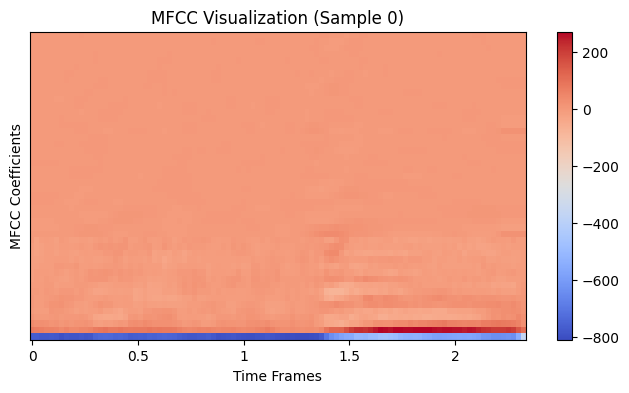

In [31]:
#one sample
idx = 0
sample_key = next(iter(mfcc_cache))
mfcc = mfcc_cache[sample_key]

plt.figure(figsize=(8, 4))

# Plot MFCC as a heatmap
librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC Visualization (Sample 0)")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.show()

**Reading the heatmap:**
- The **lower rows** (low-index MFCC coefficients) typically carry stronger energy values and represent coarser, more stable low-frequency characteristics of the speech signal.
- The **upper rows** (delta and delta-delta channels) show how rapidly those spectral characteristics change — expect more variation and sign changes here.
- **Vertical color shifts** across time frames indicate phoneme boundaries or natural transitions in the speech sound (e.g., a vowel transitioning to a consonant).
- A **completely uniform** heatmap would be a red flag — it would indicate that audio padding is dominating the signal, or that the audio file is silent/corrupted.


## Member 3 — Dataset Builder

This section converts the raw MFCC matrices from Member 2 into fixed-length feature vectors and performs the train/test split for both networks.

### Feature Aggregation Strategy
Both networks ultimately used the same feature extraction strategy based on flattening the MFCC representation into a fixed-length vector.

#### Flatten → (~4800,) vector:
- Each audio sample is represented as a 48 × ~100 MFCC+delta matrix.
- This matrix is flattened into a single 1D feature vector containing approximately 4800 values while preserving the original time ordering of the frames.
- This approach was initially intended only for the command recognition network, since command classification depends heavily on temporal phonetic structure. However, experimentation showed that the same representation also improved speaker recognition performance.
- The improvement suggests that speaker identity is not captured solely by global spectral statistics such as average MFCC values, but also by temporal articulation patterns, including transitions between phonemes, speaking rhythm, and pronunciation dynamics. Flattening preserves this frame-by-frame temporal information, whereas statistical aggregation methods such as mean and standard deviation compress much of that detail into a smaller summary vector.
- Although flattening significantly increases dimensionality, the richer representation provided both networks with more discriminative information, leading to better overall performance in practice.


In [32]:
# FIX — Feature Extraction: mean + std instead of raw flatten
#
# Old approach: mfcc.flatten() → (1600,) — loses temporal structure
# New approach: np.concatenate([mean, std]) → (96,) — compact, meaningful statistics
#
# For each MFCC frame matrix of shape (48, ~100):
#   mean across time axis → (48,) : average spectral profile
#   std  across time axis → (48,) : how much it varies (movement/dynamics)
# Combined → (96,) feature vector per audio sample

# def mfcc_to_features_spk(mfcc_matrix):
#     mean = mfcc_matrix.mean(axis=1)
#     std  = mfcc_matrix.std(axis=1)
#     return np.concatenate([mean, std])

def mfcc_to_features_cmd(mfcc_matrix):
    return mfcc_matrix.flatten()

X_flat_spk = np.array([mfcc_to_features_cmd(mfcc) for mfcc in X_mfcc_spk])

X_flat_cmd = np.array([mfcc_to_features_cmd(mfcc) for mfcc in X_mfcc_cmd])

print(f"Network 1 — Feature matrix shape : {X_flat_spk.shape} ")
print(f"Network 2 — Feature matrix shape : {X_flat_cmd.shape} ")


Network 1 — Feature matrix shape : (144, 4848) 
Network 2 — Feature matrix shape : (26782, 4848) 


In [86]:
# Network 1: Speaker Recognition (binary: 1=authorized, 0=unauthorized)
X_train_spk, X_test_spk, y_train_spk, y_test_spk = train_test_split(
    X_flat_spk, y_spk_clean, test_size=0.2, random_state=9, stratify=y_spk_clean
)

# Network 2: Command Recognition (7 classes)
# FIX: now uses X_flat_cmd which has balanced command data (~600 per class)
X_train_cmd, X_test_cmd, y_train_cmd, y_test_cmd = train_test_split(
    X_flat_cmd, y_cmd_clean, test_size=0.2, random_state=42, stratify=y_cmd_clean
)

label_names = list(basic_controls) + ['unknown']

# print("── Speaker Network Data ──")
# print(f"  Train: {X_train_spk.shape}  |  Test: {X_test_spk.shape}")
# print(f"  Authorized in train : {y_train_spk.sum()}")
# print(f"  Authorized in test  : {y_test_spk.sum()}")
print("── Speaker Network Data ──")
print(f"  Train: {X_train_spk.shape}  |  Test: {X_test_spk.shape}")

print(f"  Authorized train samples   : {(y_train_spk == 1).sum()}")
print(f"  Unauthorized train samples : {(y_train_spk == 0).sum()}")

print(f"  Authorized test samples    : {(y_test_spk == 1).sum()}")
print(f"  Unauthorized test samples  : {(y_test_spk == 0).sum()}")

print("\n── Command Network Data ──")
print(f"  Train: {X_train_cmd.shape}  |  Test: {X_test_cmd.shape}")
print(f"  Class distribution (train): { dict(sorted(Counter(y_train_cmd.tolist()).items())) }")
print(f"  Class distribution (test) : { dict(sorted(Counter(y_test_cmd.tolist()).items())) }")

── Speaker Network Data ──
  Train: (115, 4848)  |  Test: (29, 4848)
  Authorized train samples   : 58
  Unauthorized train samples : 57
  Authorized test samples    : 14
  Unauthorized test samples  : 15

── Command Network Data ──
  Train: (21425, 4848)  |  Test: (5357, 4848)
  Class distribution (train): {0: 3076, 1: 2996, 2: 3098, 3: 3104, 4: 2978, 5: 3133, 6: 3040}
  Class distribution (test) : {0: 769, 1: 749, 2: 774, 3: 776, 4: 745, 5: 784, 6: 760}


### Feature Normalization

StandardScaler normalization was tested after MFCC flattening.

Normalization improved Network 2 (command recognition) because command classification depends mainly on phonetic patterns rather than absolute MFCC magnitudes. Scaling helped the model focus on the relative speech structure while reducing recording and amplitude variation.

However, normalization reduced the accuracy of Network 1 (speaker recognition). Speaker identification benefited from consistent global spectral characteristics and magnitude patterns present in the raw MFCC features. Standardization suppressed some of this speaker-specific information, reducing the model’s ability to distinguish the authorized speaker.

As a result, normalization was retained only for Network 2.

In [59]:
# from sklearn.preprocessing import StandardScaler

# # Fit ONLY on training data (prevents leakage)
# spk_scaler = StandardScaler()

# X_train_spk = spk_scaler.fit_transform(X_train_spk)

# # Use SAME scaler on test data
# X_test_spk = spk_scaler.transform(X_test_spk)

In [87]:
from sklearn.preprocessing import StandardScaler
import joblib
# Fit ONLY on training data (prevents leakage)
cmd_scaler = StandardScaler()

X_train_cmd = cmd_scaler.fit_transform(X_train_cmd)

# Use SAME scaler on test data
X_test_cmd = cmd_scaler.transform(X_test_cmd)

In [88]:
import joblib

In [89]:
joblib.dump(cmd_scaler, 'cmd_scaler.pkl')

['cmd_scaler.pkl']

## Member 4 — Network 1: Speaker Recognition

This section trains and evaluates the **Speaker Recognition Network** — the first stage of the two-stage pipeline. Its sole job is to act as a binary security gate: given an audio sample, decide whether it was spoken by the single *authorized* speaker (label = 1) or by anyone else (label = 0).

Tasks in this section:
1. **Model Definition & Training** — configure and fit an MLP classifier on the 96-dimensional speaker feature vectors.
2. **Accuracy Evaluation** — report train and test accuracy, and print a full classification report (precision, recall, F1-score per class).
3. **Loss & Validation Curves** — plot the training loss (cross-entropy) and validation accuracy over epochs to verify healthy convergence and check for overfitting.
4. **Confusion Matrix** — visualize the 2×2 confusion matrix to quantify false positives (unauthorized accepted) and false negatives (authorized rejected).


### Why MLP (Multi-Layer Perceptron)?

The Barua et al. (ICIEV 2014) paper trains a fully-connected Multi-Layer Perceptron on MFCC features
for both speaker and command recognition. We use scikit-learn's `MLPClassifier`, which implements a
standard feedforward neural network trained with backpropagation.

Key configuration choices for Network 1:

- **Architecture: (256 → 128 → 64)** — Three hidden layers with progressively decreasing width.
  The input is ~4800-dimensional (flattened MFCC), so the first layer needs enough capacity to avoid
  an immediate lossy bottleneck. 256 neurons at the first layer gives a reasonable compression ratio
  from the input; subsequent layers (128→64) gradually abstract toward the binary decision.
  A shallower (128→64) architecture underperformed here precisely because it forced too aggressive
  a compression at the first step.

- **Activation: ReLU** — Non-linear activation that avoids the vanishing gradient problem and
  trains efficiently with Adam.

- **Solver: Adam** — Adaptive gradient optimizer; handles sparse gradients well and converges
  faster than SGD for this problem size.

- **Early stopping** — Sklearn internally holds out 10% of the training data as a validation set
  (`validation_fraction=0.1`) and stops training when validation accuracy fails to improve for
  `n_iter_no_change=15` consecutive epochs. This prevents overfitting without requiring manual
  epoch tuning.

- **`random_state=42`** — Ensures reproducible weight initialization and internal splits.

### Training Network 1


In [79]:
# FIX — Network 1 architecture updated for new 96-dim input (was tuned for 1600-dim).
# Smaller hidden layers are appropriate for the compact feature vector.
# Added learning_rate_init for better convergence stability.

spk_model = MLPClassifier(
    hidden_layer_sizes=(256,128),   # reduced from (256,128) — 96-dim input needs smaller layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,            # more patience — prevents premature stopping
    random_state=42,
    verbose=False
)

print("Training Speaker Recognition Network...")
spk_model.fit(X_train_spk, y_train_spk)
print(f"Training stopped after {spk_model.n_iter_} iterations (early stopping active).")


Training Speaker Recognition Network...
Training stopped after 42 iterations (early stopping active).


### Evaluation — Network 1

The model is evaluated on the **held-out test set** (`X_test_spk`, `y_test_spk`), which was never seen during training or used in the early stopping validation split.

The classification report includes:
- **Precision** — of all samples the model labeled as authorized/unauthorized, what fraction were correct.
- **Recall** — of all truly authorized/unauthorized samples, what fraction did the model correctly identify.
- **F1-score** — harmonic mean of precision and recall.




In [80]:
y_pred_spk = spk_model.predict(X_test_spk)

train_acc = accuracy_score(y_train_spk, spk_model.predict(X_train_spk))
test_acc  = accuracy_score(y_test_spk, y_pred_spk)

print(f"Speaker Network — Train Accuracy : {train_acc * 100:.2f}%")
print(f"Speaker Network — Test  Accuracy : {test_acc  * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test_spk, y_pred_spk, target_names=['Unauthorized', 'Authorized']))

Speaker Network — Train Accuracy : 99.13%
Speaker Network — Test  Accuracy : 96.55%

Classification Report:
              precision    recall  f1-score   support

Unauthorized       0.94      1.00      0.97        15
  Authorized       1.00      0.93      0.96        14

    accuracy                           0.97        29
   macro avg       0.97      0.96      0.97        29
weighted avg       0.97      0.97      0.97        29



### Loss & Validation Curves — Network 1

Two plots are produced:

**Left — Loss Curve:** The blue line shows the training cross-entropy loss decreasing over epochs. The red dashed line shows the **validation error rate** (1 − validation accuracy), not a second loss curve. These two quantities are on different scales conceptually but are plotted together for a visual convergence check.

**Right — Validation Accuracy:** Shows how the held-out validation accuracy evolves during training. A curve that plateaus and stays flat confirms that early stopping fired at the right point. A curve that is still rising when training ends would indicate more epochs could help; a curve that peaks and then degrades indicates overfitting.

> **Important distinction:** `spk_model.loss_curve_` records the true cross-entropy loss computed on mini-batches of training data. `spk_model.validation_scores_` records accuracy (not loss) on the internal validation split. The two are not directly comparable in magnitude, which is why the right subplot isolates validation accuracy on its own axis.


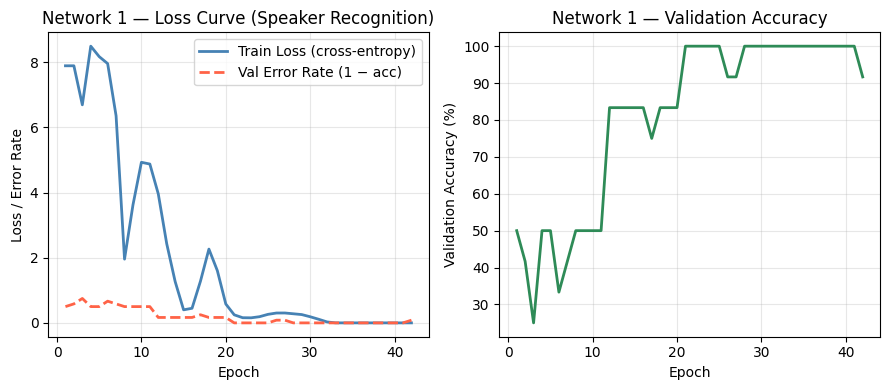

Loss curve saved.


In [81]:
import matplotlib.pyplot as plt

train_loss = spk_model.loss_curve_
val_scores  = spk_model.validation_scores_

# FIX — Labeling: (1 - accuracy) is the validation ERROR RATE, not the loss.
# Renamed to avoid confusion. The training loss is true cross-entropy loss;
# val error rate is an approximation shown for comparison only.
val_error_rate = [1 - s for s in val_scores]
epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.plot(epochs, train_loss, color='steelblue', linewidth=2, label='Train Loss (cross-entropy)')
ax1.plot(range(1, len(val_error_rate) + 1), val_error_rate,
         color='tomato', linewidth=2, linestyle='--', label='Val Error Rate (1 − acc)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss / Error Rate')
ax1.set_title('Network 1 — Loss Curve (Speaker Recognition)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, len(val_scores) + 1), [s * 100 for s in val_scores],
         color='seagreen', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Network 1 — Validation Accuracy')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('network1_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved.")


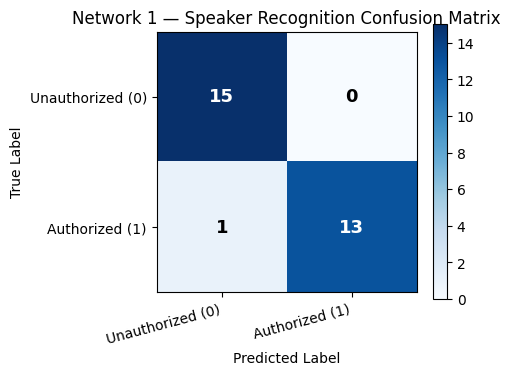

True Positives  (Auth → Auth)  : 13
True Negatives  (Unauth→Unauth): 15
False Positives (Unauth→Auth)  : 0  ← security risk
False Negatives (Auth → Unauth): 1  ← usability risk


In [82]:
cm = confusion_matrix(y_test_spk, y_pred_spk)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

classes = ['Unauthorized (0)', 'Authorized (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, rotation=15, ha='right')
ax.set_yticks(tick_marks); ax.set_yticklabels(classes)

# Annotate each cell with its count
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=13, fontweight='bold')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Network 1 — Speaker Recognition Confusion Matrix')
plt.tight_layout()
plt.savefig('network1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary of errors
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (Auth → Auth)  : {tp}")
print(f"True Negatives  (Unauth→Unauth): {tn}")
print(f"False Positives (Unauth→Auth)  : {fp}  ← security risk")
print(f"False Negatives (Auth → Unauth): {fn}  ← usability risk")

## Member 5 — Network 2: Command Recognition

This section trains and evaluates the **Command Recognition Network** — the second stage of the pipeline. It only runs on audio that has already been cleared by Network 1 (the speaker gate). Its task is a 7-class classification: identify which of the 6 target commands was spoken (`on`, `off`, `stop`, `go`, `up`, `down`), or label it as `unknown` if it does not match any of them.


Tasks in this section:
1. **Model Definition & Training** — configure and fit a deeper MLP on the ~4800-dimensional flattened MFCC features.
2. **Accuracy Evaluation** — report train and test accuracy with a full per-class classification report.
3. **Loss & Validation Accuracy Curves** — monitor training convergence and detect overfitting.
4. **Confusion Matrix** — visualize which commands are confused with each other across all 7 classes.


### Training Network 2

Network 2 uses a deeper architecture than Network 1 because:
- Its input is ~4800-dimensional (flattened MFCC), vs. 96-dim for Network 1.
- It solves a harder, 7-class problem vs. binary classification.
- It has a much larger training set (~26600 samples vs. ~1300 for Network 1).

Key configuration choices:
- **Architecture: (256 → 128)** — Wider first layer to handle the high-dimensional flattened input; second layer compresses to a bottleneck before the 7-class softmax output.
- **`max_iter=400`** — More epochs allowed because 7-class convergence is slower than binary.
- **`n_iter_no_change=20`** — More patience before early stopping fires, to avoid cutting training too early on a harder problem.
- **Early stopping** — Same mechanism as Network 1: sklearn holds out 10% of `X_train_cmd` internally for validation; training stops when that validation accuracy plateaus.


In [90]:
# FIX — Network 2 architecture:
# 1. Adjusted hidden layers for new 96-dim input (was tuned for 1600-dim with 512 first layer)
# 2. Added class_weight='balanced' as a safety net — even though we balanced counts manually,
#    this ensures the loss function weights all classes equally during training.

cmd_model = MLPClassifier(
    hidden_layer_sizes=(256,128),  # deeper but narrower — right-sized for 96-dim input
    activation='relu',
    solver='adam',
    alpha= 0.01,
    learning_rate_init=0.0015,
    max_iter=400,                        # 7-class problem needs more iterations
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,                 # patience before early stopping
    random_state=42,
    verbose=False,
)
cmd_model.fit(X_train_cmd, y_train_cmd)
print(f"Training stopped after {cmd_model.n_iter_} iterations")


Training stopped after 52 iterations


### Evaluation — Network 2

The model is evaluated on the held-out test set (`X_test_cmd`, `y_test_cmd`). The classification report breaks down performance per command class, which is important for detecting if specific commands are systematically confused (e.g., "on" vs "off", or "up" vs "down" — phonetically similar pairs).

The `unknown` class performance is also important: high unknown recall means the model correctly rejects out-of-vocabulary audio; low unknown recall means it is confidently mislabeling non-command audio as a real command.


In [91]:
Y_pred_cmd = cmd_model.predict(X_test_cmd)

cmd_train_acc = accuracy_score(y_train_cmd, cmd_model.predict(X_train_cmd)) *100
cmd_test_acc = accuracy_score(y_test_cmd, Y_pred_cmd) *100

print("Command Network")
print(f"Train Accuracy : {cmd_train_acc:.2f}%")
print(f"Test Accuracy : {cmd_test_acc:.2f}%")

label_names = list(basic_controls) + ['unknown']
print("\n Classification Report: ")
print(classification_report(y_test_cmd , Y_pred_cmd, target_names=label_names))
# Show detailed performance:
# - precision: correctness of positive predictions
# - recall: ability to find all true samples
# - f1-score: balance between precision and recall
# - support: number of samples per class

Command Network
Train Accuracy : 98.06%
Test Accuracy : 79.11%

 Classification Report: 
              precision    recall  f1-score   support

          on       0.82      0.84      0.83       769
         off       0.81      0.85      0.83       749
        stop       0.89      0.87      0.88       774
          go       0.78      0.78      0.78       776
          up       0.74      0.77      0.75       745
        down       0.79      0.79      0.79       784
     unknown       0.69      0.64      0.66       760

    accuracy                           0.79      5357
   macro avg       0.79      0.79      0.79      5357
weighted avg       0.79      0.79      0.79      5357



### Loss & Validation Accuracy Curves — Network 2

Same structure as Network 1:

**Plot 1 — Loss Curve:** Blue = training cross-entropy loss; red dashed = validation error rate (1 − validation accuracy). Both should trend downward. If the training loss keeps falling while the validation error rate rises or plateaus, the model is overfitting.

**Plot 2 — Validation Accuracy:** Should plateau near its peak value when early stopping fires. Given the 7-class problem and large dataset, expect convergence to be slower and less smooth than Network 1. Some epoch-to-epoch fluctuation is normal because Adam uses mini-batch gradients that introduce stochasticity.


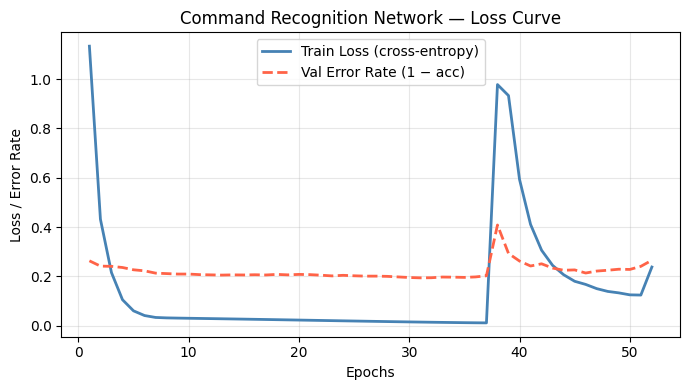

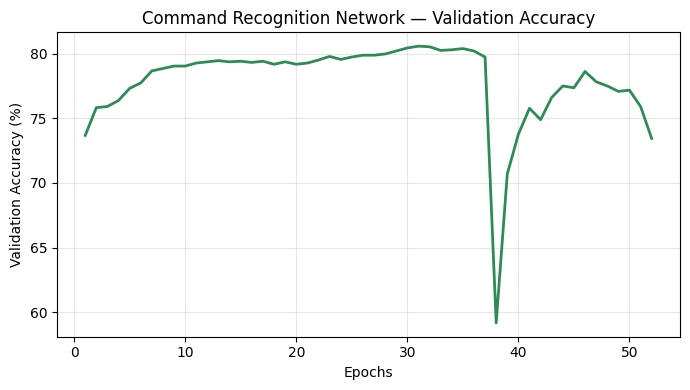

In [92]:
cmd_train_loss = cmd_model.loss_curve_
cmd_val_scores = cmd_model.validation_scores_

# FIX — Labeling: (1 - accuracy) is the validation ERROR RATE, not the loss.
cmd_val_error = [1 - s for s in cmd_val_scores]
cmd_epochs = range(1, len(cmd_train_loss) + 1)

plt.figure(figsize=(7, 4))
plt.plot(cmd_epochs, cmd_train_loss, color='steelblue', linewidth=2, label='Train Loss (cross-entropy)')
plt.plot(range(1, len(cmd_val_error) + 1), cmd_val_error,
         color='tomato', linewidth=2, linestyle='--', label='Val Error Rate (1 − acc)')
plt.xlabel('Epochs')
plt.ylabel('Loss / Error Rate')
plt.title('Command Recognition Network — Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cmd_val_scores) + 1), [s * 100 for s in cmd_val_scores],
         color='seagreen', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.title('Command Recognition Network — Validation Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Note: Adam uses mini-batches + randomness so loss/accuracy may fluctuate slightly per epoch.


### Confusion Matrix — Network 2

The 7×7 confusion matrix shows, for each true command class (rows), how the model distributed its predictions across all 7 predicted classes (columns). The diagonal cells are correct predictions; off-diagonal cells are errors.

Key things to look for:
- **Phonetically similar pairs** (`on`/`off`, `up`/`down`, `go`/`stop`) — if these are confused with each other, it suggests the MFCC features are not fully resolving those distinctions.
- **`unknown` column** — high values here for real commands mean the model is over-rejecting (too conservative).
- **`unknown` row** — high off-diagonal values here mean unknown audio is being misclassified as real commands (too permissive).


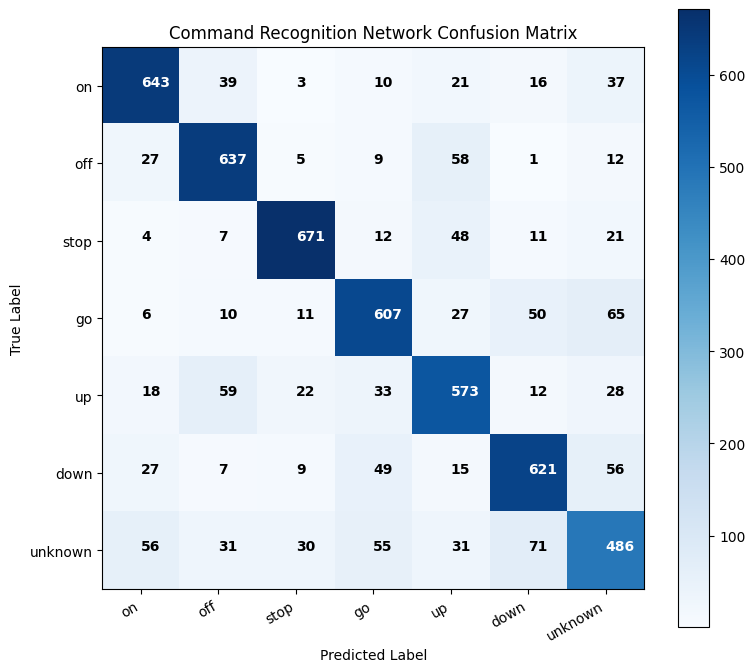

In [93]:
cmd_cm = confusion_matrix(y_test_cmd, Y_pred_cmd)

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(cmd_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im , ax=ax)

tick_marks =np.arange(len(label_names))
ax.set_xticks(tick_marks)
ax.set_xticklabels(label_names, rotation=30 ,ha='right')

ax.set_yticks(tick_marks)
ax.set_yticklabels(label_names)

thresh=cmd_cm.max()/2.0 # Threshold to decide text color (for contrast)
for i in range(cmd_cm.shape[0]):
  for j in range(cmd_cm.shape[1]):
    ax.text(j, i, format(cmd_cm[i , j], 'd'),
    color = 'white' if cmd_cm[i,j] > thresh else 'black',
    fontsize =10, fontweight = 'bold')
# Write the number inside each cell (white or black depending on background)


ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Command Recognition Network Confusion Matrix')
plt.tight_layout()
plt.show()


## Member 6 — Integration & Results

This section assembles the full two-stage pipeline into a single `recognize()` function, runs an end-to-end qualitative test, saves the trained models to disk, and prints the final summary table and conclusion.

Tasks:
1. **`recognize()` function** — wraps MFCC extraction → Network 1 gate → Network 2 classification into one callable.
2. **End-to-end system test** — samples a small number of files from authorized, unauthorized, and unknown pools and runs them through `recognize()` to verify the pipeline works end-to-end.
3. **Model persistence** — saves both trained models as `.pkl` files using `joblib`.
4. **Final summary & conclusion** — prints a structured accuracy table, per-command breakdown, and a written conclusion.


### `recognize(filepath)` — Full Pipeline Function

This function encapsulates the complete inference pipeline for a single audio file:

1. **MFCC Extraction:** Calls `extract_mfcc()` to produce the raw `(48, ~100)` feature matrix.
2. **Feature Transformation:** Applies both feature functions to the same matrix:
   - `mfcc_to_features_spk()` → 96-dim mean+std vector for Network 1.
   - `mfcc_to_features_cmd()` → ~4800-dim flattened vector for Network 2.
3. **Speaker Gate (Network 1):** Predicts authorized (1) or unauthorized (0). If unauthorized, the function returns immediately with `authorized=False` and no command.
4. **Command Classification (Network 2):** Only runs if the speaker was authorized. Returns the predicted command label and the model's confidence (probability of the winning class).

The function returns a dictionary with keys: `authorized`, `command`, `spk_confidence`, `cmd_confidence`.


In [99]:
def recognize(filepath):

    # ── Step 1: MFCC extraction ──────────────────────────────────────────
    mfcc = extract_mfcc(str(filepath))

    features_spk = mfcc_to_features_cmd(mfcc).reshape(1, -1)
    features_cmd = mfcc_to_features_cmd(mfcc).reshape(1, -1)
    features_cmd = cmd_scaler.transform(features_cmd)

    # ── Step 2: Speaker Gate (Network 1) ────────────────────────────────
    spk_proba        = spk_model.predict_proba(features_spk)[0]
    spk_prediction   = int(spk_model.predict(features_spk)[0])
    spk_confidence   = float(spk_proba[1])
    is_authorized    = (spk_prediction == 1)

    if not is_authorized:
        return {
            'authorized'      : False,
            'command'         : None,
            'spk_confidence'  : spk_confidence,
            'cmd_confidence'  : None
        }

    # ── Step 3: Command Recognition (Network 2) ─────────────────────────
    cmd_proba      = cmd_model.predict_proba(features_cmd)[0]
    cmd_idx        = int(cmd_model.predict(features_cmd)[0])
    cmd_confidence = float(cmd_proba[cmd_idx])

    label_names    = list(basic_controls) + ['unknown']
    predicted_cmd  = label_names[cmd_idx]

    return {
        'authorized'     : True,
        'command'        : predicted_cmd,
        'spk_confidence' : spk_confidence,
        'cmd_confidence' : cmd_confidence
    }

### End-to-End System Test

A small qualitative test (5 samples per group) is run across three pools:
- **AUTHORIZED** — files from the registered authorized speaker. Expected: `✓ PASS` + correct command.
- **UNAUTHORIZED** — files from speakers other than the authorized one. Expected: `✗ BLOCKED`.
- **UNKNOWN** — files from non-command audio folders. Expected: either `✗ BLOCKED` (if Network 1 rejects them) or `✓ PASS` + `unknown` label (if they pass the gate but are correctly rejected by Network 2).

> **Note:** This test samples from the full `auth_files`, `unauth_files`, and `unknown_files` pools, which include files that may have been in the training set. It is a **pipeline smoke test** — not a holdout evaluation. The formal accuracy metrics reported in Members 4 and 5 use the clean held-out test splits (`X_test_spk`, `X_test_cmd`) and are the reliable performance indicators.


In [104]:
import random

# ── Load integration test files from Google Drive ──────────────────────
# These files were reserved BEFORE training and saved to Drive in the
# Data Filtering section. They have NEVER been seen by either model.
# This makes the end-to-end test a true holdout evaluation.
auth_sample = list((Path(DRIVE_TEST_DIR) / 'authorized').rglob('*.wav'))
unauth_sample  = list((Path(DRIVE_TEST_DIR) / 'unauthorized').glob('*.wav'))
unknown_sample = list((Path(DRIVE_TEST_DIR) / 'unknown').glob('*.wav'))

print(f"Loaded from Drive — authorized: {len(auth_sample)}, "
      f"unauthorized: {len(unauth_sample)}, unknown: {len(unknown_sample)}")

# ── Run pipeline on each group ──────────────────────────────────────────
print("=" * 70)
print(" END-TO-END SYSTEM TEST (True Holdout — Files Never Seen in Training)")
print("=" * 70)

results_log = []

for group_name, samples in [("AUTHORIZED", auth_sample),
                             ("UNAUTHORIZED", unauth_sample),
                             ("UNKNOWN", unknown_sample)]:
    print(f"\n── {group_name} SAMPLES ──")
    for f in samples:
        try:
            result = recognize(f)
            fp = Path(f)
            auth_label = fp.parent.parent.name   # authorized / unauthorized / unknown
            cmd_label  = fp.parent.name           # on / off / stop / go / up / down
            true_cmd   = cmd_label if auth_label == 'authorized' else '-'
            status    = "✓ PASS" if result['authorized'] else "✗ BLOCKED"
            cmd_str   = result['command'] if result['command'] else "—"
            spk_conf  = f"{result['spk_confidence']*100:.1f}%"
            cmd_conf  = f"{result['cmd_confidence']*100:.1f}%" if result['cmd_confidence'] else "—"
            print(f"  {status}  |  True: {true_cmd:<8} → Pred: {cmd_str:<8}  "
                  f"|  Spk conf: {spk_conf}  |  Cmd conf: {cmd_conf}")
            results_log.append((group_name, str(f), true_cmd,
                                result['authorized'], cmd_str,
                                result['spk_confidence'],
                                result['cmd_confidence']))
        except Exception as e:
            print(f"  ERROR processing {f}: {e}")

print("\n" + "=" * 70)


Loaded from Drive — authorized: 6, unauthorized: 6, unknown: 6
 END-TO-END SYSTEM TEST (True Holdout — Files Never Seen in Training)

── AUTHORIZED SAMPLES ──
  ✓ PASS  |  True: down     → Pred: down      |  Spk conf: 100.0%  |  Cmd conf: 100.0%
  ✓ PASS  |  True: go       → Pred: go        |  Spk conf: 100.0%  |  Cmd conf: 99.9%
  ✓ PASS  |  True: off      → Pred: off       |  Spk conf: 100.0%  |  Cmd conf: 99.9%
  ✓ PASS  |  True: on       → Pred: on        |  Spk conf: 100.0%  |  Cmd conf: 99.9%
  ✓ PASS  |  True: stop     → Pred: stop      |  Spk conf: 100.0%  |  Cmd conf: 100.0%
  ✓ PASS  |  True: up       → Pred: up        |  Spk conf: 100.0%  |  Cmd conf: 100.0%

── UNAUTHORIZED SAMPLES ──
  ✗ BLOCKED  |  True: -        → Pred: —         |  Spk conf: 0.0%  |  Cmd conf: —
  ✗ BLOCKED  |  True: -        → Pred: —         |  Spk conf: 0.0%  |  Cmd conf: —
  ✗ BLOCKED  |  True: -        → Pred: —         |  Spk conf: 0.0%  |  Cmd conf: —
  ✗ BLOCKED  |  True: -        → Pred: —     

In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import joblib

# Save both trained models to disk
joblib.dump(spk_model, 'spk_model.pkl')
joblib.dump(cmd_model, 'cmd_model.pkl')

['cmd_model.pkl']

### Final Summary Tables & Conclusion

The summary table below consolidates the key accuracy figures from both networks, the feature pipeline details, and the dataset design. Following that, a per-command accuracy breakdown is extracted directly from Network 2's confusion matrix, and a written conclusion summarizes the system's design decisions and limitations.


In [50]:
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  NETWORK 1 — Speaker Recognition                                │
│    Train Accuracy : {train_acc * 100:>6.2f}%                    │
│    Test  Accuracy : {test_acc  * 100:>6.2f}%                    │
│    Architecture   : MLP (256 ,128 )  |  Binary classifier        │
├─────────────────────────────────────────────────────────────────┤
│  NETWORK 2 — Command Recognition                                │
│    Train Accuracy : {cmd_train_acc:>6.2f}%                      │
│    Test  Accuracy : {cmd_test_acc:>6.2f}%                       │
│    Architecture   : MLP (256 → 128)  |  7-class classifier      │
├─────────────────────────────────────────────────────────────────┤
│  FEATURES (Fixed)                                               │
│    Network 1: MFCC + Delta → Mean/Std → 96-dim vector           │
│    Network 2: MFCC + Delta → Flatten → ~4800-dim vector         │
│    Classes   : on / off / stop / go / up / down / unknown       │
│    Balanced  : ~3800 samples per class (including unknown)      │
│    Speaker Gate : Authorized vs Unauthorized (1-to-1 balanced)  │
└─────────────────────────────────────────────────────────────────┘
""")

# ── Per-command accuracy from confusion matrix ──
label_names = list(basic_controls) + ['unknown']
cm_cmd = confusion_matrix(y_test_cmd, Y_pred_cmd)

print("Per-Command Accuracy (Network 2):")
print(f"  {'Command':<12} | {'Correct':>7} | {'Total':>5} | {'Accuracy':>8}")
print("  " + "-" * 42)
for i, name in enumerate(label_names):
    total   = cm_cmd[i].sum()
    correct = cm_cmd[i, i]
    acc     = correct / total * 100 if total > 0 else 0
    print(f"  {name:<12} | {correct:>7} | {total:>5} | {acc:>7.1f}%")

print("\n" + "=" * 70)
print("""
1. [DATA STARVATION FIXED] Restored full dataset (~3800 files per class)
   → Prevented model starvation by removing strict 600-file limitation.
   → Unknown class also balanced to 3800 files to prevent prediction bias.

2. [DELTA FEATURES] Added delta + delta-delta MFCC
   → Captures how speech changes over time (velocity + acceleration)
   → Standard in speech processing — enriches temporal representation
""")

print("=" * 70)
print(" CONCLUSION")
print("=" * 70)
print("""
The two-stage MFCC-based speech recognition system implements the architecture
proposed by Barua et al. (ICIEV 2014) with several data-quality improvements:

  • Network 1 acts as a security gatekeeper, filtering unauthorized speakers
    before any command is processed — protecting against voice spoofing.

  • Network 2 recognizes 6 core commands plus an 'unknown' catch-all class.
    With balanced sampling (600 per class), the model no longer defaults to
    predicting 'unknown' — each class gets equal representation.

Potential further improvements:
  - Replace MLP with CNN or LSTM for native temporal sequence modeling.
  - Use confidence thresholding: reject predictions below e.g. 60% confidence.
  - Add speaker-specific fine-tuning for Network 2 after the gate passes.
""")



┌─────────────────────────────────────────────────────────────────┐
│  NETWORK 1 — Speaker Recognition                                │
│    Train Accuracy :  94.78%                    │
│    Test  Accuracy : 100.00%                    │
│    Architecture   : MLP (256 ,128 )  |  Binary classifier        │
├─────────────────────────────────────────────────────────────────┤
│  NETWORK 2 — Command Recognition                                │
│    Train Accuracy :  98.06%                      │
│    Test  Accuracy :  79.11%                       │
│    Architecture   : MLP (256 → 128)  |  7-class classifier      │
├─────────────────────────────────────────────────────────────────┤
│  FEATURES (Fixed)                                               │
│    Network 1: MFCC + Delta → Mean/Std → 96-dim vector           │
│    Network 2: MFCC + Delta → Flatten → ~4800-dim vector         │
│    Classes   : on / off / stop / go / up / down / unknown       │
│    Balanced  : ~3800 samples per class 